In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the dataset**

In [ ]:
df=pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Data understanding and cleaning**

In [ ]:
print("Dataset Shape:", df.shape)
print(df.info())

missing_values = df.isnull().sum().sort_values(ascending=False) #check missing value

print("\nTop missing values:")
print(missing_values[missing_values > 0].head(20))

Dataset Shape: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-nu

**Handling Missing Value**

In [ ]:
#1. Split numeric and categorical columns

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 38
Categorical columns: 43


In [ ]:
#2. Handle numeric missing values

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)  #Fill with Median (not affected by outliers)

print("Numeric missing values handled")

Numeric missing values handled


/tmp/ipykernel_12011/1373200901.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)  #Fill with Median (not affected by outliers)


In [ ]:
#3. Handle Categorical Missing values

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True) # Fill with mode (most frequent value)
                                                    #mode()[0] tells the first frequent occured value

print("Categorical missing values handled")

#Final check
print("\nRemaining missing values:", df.isnull().sum().sum())  #First sum is to count missing values per column & Second sum adds all columns together

Categorical missing values handled

Remaining missing values: 0


/tmp/ipykernel_12011/2568612372.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True) # Fill with mode (most frequent value)


**Encoding Categorical Variables**

In [ ]:
#One-Hot Encoding (Best for this dataset)

df_encoded = pd.get_dummies(df, drop_first=True)

print("Original shape:", df.shape)
print("New shape after encoding:", df_encoded.shape)

Original shape: (1460, 81)
New shape after encoding: (1460, 246)


**Train-test split and Linear Regression**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = df_encoded.drop("SalePrice", axis=1)  #Split features and target
y = df_encoded["SalePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Train-Test split
print("Data split completed")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)    #Train Linear Regression Model
print("Linear Regression model trained")

y_pred = lr_model.predict(X_test) #Prediction

#Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMODEL PERFORMANCE")
print("MAE (Mean Absolute Error):", mae)
print("RMSE (Root Mean Squared Error):", rmse)

Features shape: (1460, 245)
Target shape: (1460,)
Data split completed
Linear Regression model trained

MODEL PERFORMANCE
MAE (Mean Absolute Error): 20232.175887935042
RMSE (Root Mean Squared Error): 51405.09425333483


**Random Forest Regressor & Comparison**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)  #Train Random Forest Model

print("Random Forest model trained")

rf_pred = rf_model.predict(X_test) #Predictions

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))  #Evaluation

print("\nRANDOM FOREST PERFORMANCE")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Random Forest model trained

RANDOM FOREST PERFORMANCE
MAE: 17481.776643835616
RMSE: 28352.112565630196


**Comparison between Linear Regression & Random Forest Regressor**

In [ ]:
print("MODEL COMPARISON")
print("Linear Regression RMSE:", rmse)
print("Random Forest RMSE:", rf_rmse)

if rf_rmse > rmse:
    print("\nRandom Forest performs better")
else:
    print("\nLogistic Regression performs better")

MODEL COMPARISON
Linear Regression RMSE: 51405.09425333483
Random Forest RMSE: 28352.112565630196

Logistic Regression performs better


**Feature Importance Analysis**

In [ ]:
#Get Feature Importance

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)  ##Sort by importance (descending order)

print("Top 10 Important Features:")
display(feature_importance.head(10))  #display shows beautiful table format & preserves DataFrame structure

Top 10 Important Features:


,Feature,Importance
4,OverallQual,0.557449
16,GrLivArea,0.120819
12,TotalBsmtSF,0.034973
14,2ndFlrSF,0.034354
9,BsmtFinSF1,0.029543
13,1stFlrSF,0.025664
3,LotArea,0.016596
27,GarageArea,0.016203
26,GarageCars,0.012389
6,YearBuilt,0.011702


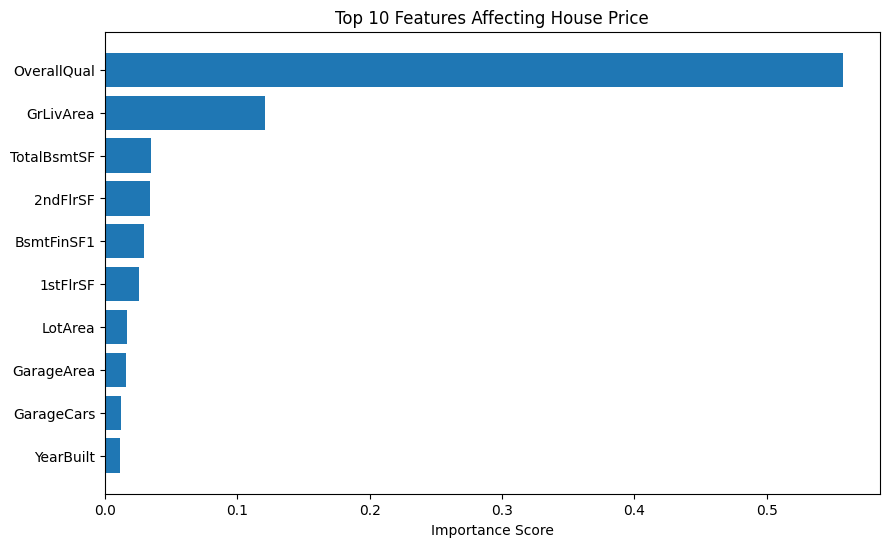

In [ ]:
#Visualization
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features["Feature"], top_features["Importance"]) #barh=horizontal bar chart between y axis and then x axis
plt.gca().invert_yaxis() #get current axes, invert y axis
#By default: smallest importance appears on top
#We reverse it so: MOST important feature appears at TOP

plt.title("Top 10 Features Affecting House Price")
plt.xlabel("Importance Score")

plt.show()

**Final Project Summary**

In [ ]:
print("HOUSE PRICE PREDICTION PROJECT COMPLETED\n")

print("PROJECT PIPELINE:")
print("Data Loading")
print("Data Cleaning (Handled missing values)")
print("Feature Engineering (One-Hot Encoding applied)")
print("Train-Test Split performed")
print("Baseline Model: Linear Regression")
print("Advanced Model: Random Forest Regressor")
print("Model Evaluation using MAE and RMSE")
print("Feature Importance Analysis completed\n")

print("KEY INSIGHTS:")
print("Overall Quality (OverallQual) is the strongest predictor of house price")
print("Living Area (GrLivArea) has a significant impact on price")
print("Garage capacity and basement area also strongly influence pricing\n")

print("FINAL OUTCOME:")
print("Successfully built a regression model to predict house prices with meaningful accuracy and interpretable insights.")

HOUSE PRICE PREDICTION PROJECT COMPLETED

PROJECT PIPELINE:
Data Loading
Data Cleaning (Handled missing values)
Feature Engineering (One-Hot Encoding applied)
Train-Test Split performed
Baseline Model: Linear Regression
Advanced Model: Random Forest Regressor
Model Evaluation using MAE and RMSE
Feature Importance Analysis completed

KEY INSIGHTS:
Overall Quality (OverallQual) is the strongest predictor of house price
Living Area (GrLivArea) has a significant impact on price
Garage capacity and basement area also strongly influence pricing

FINAL OUTCOME:
Successfully built a regression model to predict house prices with meaningful accuracy and interpretable insights.
